# Natural Language Processing: Reading/Study Notes Notebook
Ibrahem H. Ali \
**Course:** Directed Reading (Introduction to NLP)

**Bibliography:**
- Bird, Klein & Loper (2009). *Natural Language Processing with Python*. O'Reilly.
- Tunstall, von Werra & Wolf (2022). *NLP with Transformers*. O'Reilly.
- Vaswani et al. (2017). "Attention Is All You Need." *NeurIPS*.
- Mikolov et al. (2013). "Efficient Estimation of Word Representations in Vector Space." *ICLR*.
- Rush (2018). *The Annotated Transformer*. (Interactive Jupyter Notebook).

---
---

## Global Setup
It installs all dependencies and downloads NLTK corpora used throughout the notebook.

In [35]:
import subprocess, sys

pkgs = ['nltk','scikit-learn','numpy','pandas','matplotlib','seaborn','gensim']
for p in pkgs:
    subprocess.run([sys.executable,'-m','pip','install',p,'-q'], capture_output=True)

import nltk, warnings
warnings.filterwarnings('ignore')
for r in ['punkt','punkt_tab','stopwords','wordnet','averaged_perceptron_tagger',
          'averaged_perceptron_tagger_eng','maxent_ne_chunker','words',
          'movie_reviews','reuters','brown','inaugural']:
    nltk.download(r, quiet=True)

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False,
                     'axes.titlesize':13,'axes.labelsize':11})
print(' Setup complete.')

 Setup complete.


---
<a id='mod1'></a>
# Foundations & Text Preprocessing

## 1.1 What Is NLP and Why Is It Hard?

Natural Language Processing sits at the intersection of linguistics, statistics, and computer science. Its goal, as Bird, Klein & Loper (2009, Ch. 1) frame it, is to write programs that can analyze, understand, and generate human language. The qualifier "understand" is deliberately contentious, NLP systems do not understand language the way humans do; they identify statistical regularities that function as proxies for meaning.

The difficulty of NLP is not computational. It is linguistic. Human language is:

- **Ambiguous** at every level. "I saw the man with the telescope" admits two valid parses. "Bank" means something different beside a river than beside a Wall Street office.
- **Context-dependent.** "That's great" is sincere or sarcastic depending on tone and conversational history.
- **Productive.** The set of grammatical English sentences is infinite; any model must generalize from finite training data.
- **Noisy.** Real text contains typos, slang, code-switching, and domain-specific jargon.

These properties explain why rule-based NLP systems, dominant through the 1980s, gave way to statistical and then neural approaches. Rules cannot scale to unbounded linguistic variety.

## 1.2 Levels of Linguistic Analysis

Before writing a single line of code, the following table captures the linguistic stack that NLP systems climb:

| Level | Unit | Example Task |
|-------|------|--------------|
| **Phonological** | Sounds | Speech recognition |
| **Morphological** | Word structure | Stemming, lemmatization |
| **Lexical** | Words | Tokenization, POS tagging |
| **Syntactic** | Phrase structure | Parsing, chunking |
| **Semantic** | Meaning | Word sense disambiguation |
| **Discourse** | Multi-sentence | Co-reference resolution |
| **Pragmatic** | Intent in context | Sarcasm detection |

Most introductory NLP operates at the lexical through semantic levels. Discourse and pragmatics remain active research frontiers.

## 1.3 The Standard Preprocessing Pipeline

Bird et al. (2009, Ch. 3) describe preprocessing as the transformation of raw, noisy text into a normalized form suitable for downstream modeling. The canonical pipeline is:

```
Raw Text
   -> Lowercasing         , reduce vocabulary size
   -> Noise removal       , strip HTML, special chars
   -> Sentence splitting  , segment into units
   -> Tokenization        , split into words/subwords
   -> Stopword removal    , drop high-frequency function words
   -> Normalization       , stemming OR lemmatization
   ->
Clean Token Sequence
```

Each step involves a tradeoff. Removing stopwords discards "not", which is catastrophic for negation-aware sentiment analysis. Lowercasing conflates "Apple" (company) with "apple" (fruit). Sound NLP engineering means knowing when to skip a step.

## 1.4 Tokenization: The First Hard Problem

Tokenization seems trivial, split on spaces. But consider:

- `"don't"` -> `["don", "'t"]` or `["do", "n't"]` or `["don't"]`?
- `"New York"` is one entity, two tokens
- `"$1,000.00"`, is the comma a separator or part of the number?
- CJK languages (Chinese, Japanese, Korean) have no spaces at all

NLTK's `word_tokenize` uses the Penn Treebank tokenization standard, which handles English contractions and punctuation via a trained model (Bird et al., 2009, §3.7).


In [36]:
# 1.4 -- Tokenization: exploring edge cases
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize, TweetTokenizer

examples = [
    "Don't stop believing in NLP!",
    "The U.S.A. reported $1,000,000 in Q3 earnings.",
    "New York-based startup raised Series A.",
    "I loooove this model  #NLP @researcher",
]

tweet_tok = TweetTokenizer()

print(f'{"Input":<45} {"word_tokenize":<35} {"TweetTokenizer"}')
print('-'*110)
for ex in examples:
    wt = str(word_tokenize(ex)[:6]) + ('...' if len(word_tokenize(ex))>6 else '')
    tt = str(tweet_tok.tokenize(ex)[:6]) + ('...' if len(tweet_tok.tokenize(ex))>6 else '')
    print(f'{ex[:43]:<45} {wt:<35} {tt}')

print()
print('Sentence tokenization on a paragraph:')
para = "Dr. Smith visited Washington D.C. last Tuesday. He met with U.S. officials. The meeting lasted 3 hrs."
sents = sent_tokenize(para)
for i, s in enumerate(sents, 1):
    print(f'  Sent {i}: {s}')

Input                                         word_tokenize                       TweetTokenizer
--------------------------------------------------------------------------------------------------------------
Don't stop believing in NLP!                  ['Do', "n't", 'stop', 'believing', 'in', 'NLP']... ["Don't", 'stop', 'believing', 'in', 'NLP', '!']
The U.S.A. reported $1,000,000 in Q3 earnin   ['The', 'U.S.A.', 'reported', '$', '1,000,000', 'in']... ['The', 'U', '.', 'S', '.', 'A']...
New York-based startup raised Series A.       ['New', 'York-based', 'startup', 'raised', 'Series', 'A']... ['New', 'York-based', 'startup', 'raised', 'Series', 'A']...
I loooove this model  #NLP @researcher        ['I', 'loooove', 'this', 'model', '#', 'NLP']... ['I', 'loooove', 'this', 'model', '#NLP', '@researcher']

Sentence tokenization on a paragraph:
  Sent 1: Dr. Smith visited Washington D.C. last Tuesday.
  Sent 2: He met with U.S. officials.
  Sent 3: The meeting lasted 3 hrs.


In [37]:
# 1.5 -- Stemming vs Lemmatization: a systematic comparison
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer

porter   = PorterStemmer()
snowball = SnowballStemmer('english')
lemma    = WordNetLemmatizer()

test_words = ['running','flies','better','studies','corpora','happily',
              'generalization','wolves','matrices','indices']

print(f'{"Word":<16} {"Porter":<14} {"Snowball":<14} {"Lemma (v)":<14} {"Lemma (n)"}')
print('-'*72)
for w in test_words:
    p  = porter.stem(w)
    s  = snowball.stem(w)
    lv = lemma.lemmatize(w, pos='v')
    ln = lemma.lemmatize(w, pos='n')
    print(f'{w:<16} {p:<14} {s:<14} {lv:<14} {ln}')

print()
print("""Key insight:
  Stemming is fast, rule-based, and often produces non-words ('happili', 'corporacorpu').
  Lemmatization uses a lexicon (WordNet) and requires a POS tag for accuracy.
  'better' lemmatizes to 'good' only if you specify pos='a' (adjective).
  In practice: use lemmatization for tasks where word meaning matters (QA, IR),
  stemming for high-throughput classification where speed > precision.""")

Word             Porter         Snowball       Lemma (v)      Lemma (n)
------------------------------------------------------------------------
running          run            run            run            running
flies            fli            fli            fly            fly
better           better         better         better         better
studies          studi          studi          study          study
corpora          corpora        corpora        corpora        corpus
happily          happili        happili        happily        happily
generalization   gener          general        generalization generalization
wolves           wolv           wolv           wolves         wolf
matrices         matric         matric         matrices       matrix
indices          indic          indic          indices        index

Key insight:
  Stemming is fast, rule-based, and often produces non-words ('happili', 'corporacorpu').
  Lemmatization uses a lexicon (WordNet) and requires a PO

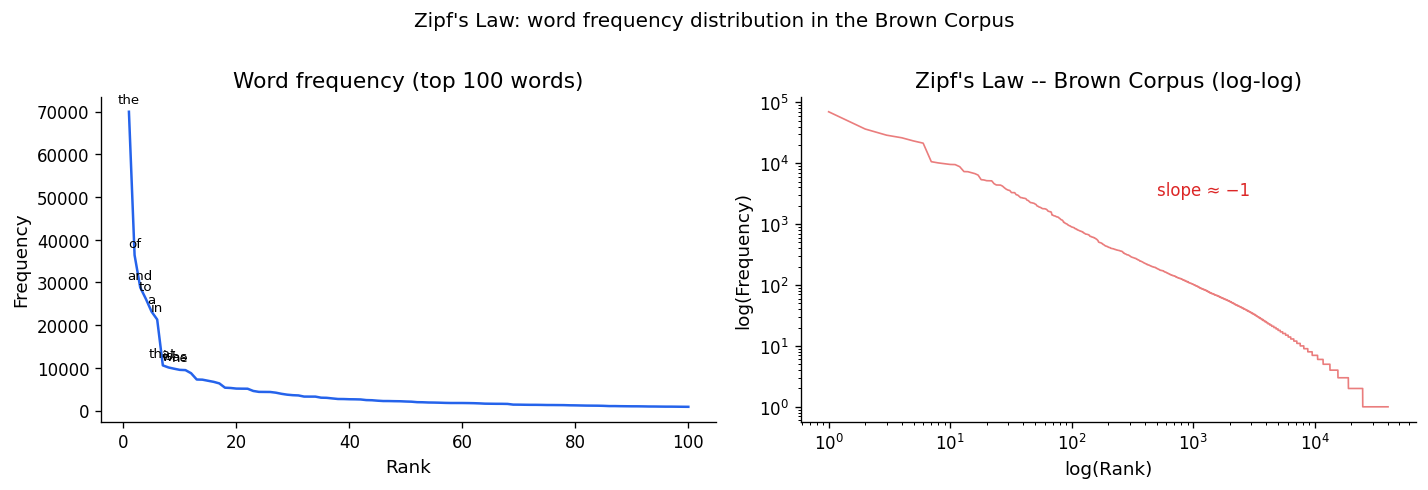

Top 50 words cover 42.0% of all tokens in the Brown Corpus.
For this reason, removing ~150 stopwords drastically reduces noise.


In [38]:
# 1.6 -- Vocabulary statistics: Zipf's Law
# Zipf's Law (1949): the frequency of a word is inversely proportional to its rank.
# f(r) ∝ 1/r      log(f) = -log(r) + C  (linear on a log-log plot)
# This is *why* stopword removal works: a tiny vocabulary covers most of the text.

from nltk.corpus import brown
from collections import Counter

words = [w.lower() for w in brown.words() if w.isalpha()]
freq  = Counter(words)
ranks = range(1, len(freq)+1)
freqs = [f for _, f in freq.most_common()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw frequency
axes[0].plot(list(ranks)[:100], freqs[:100], color='#2563eb')
axes[0].set(xlabel='Rank', ylabel='Frequency', title='Word frequency (top 100 words)')
for i, (word, f) in enumerate(freq.most_common(10)):
    axes[0].annotate(word, (i+1, f), textcoords='offset points', xytext=(0,5),
                     fontsize=8, ha='center')

# Log-log (Zipf)
axes[1].loglog(list(ranks), freqs, color='#dc2626', alpha=0.6, lw=1)
axes[1].set(xlabel='log(Rank)', ylabel='log(Frequency)', title="Zipf's Law -- Brown Corpus (log-log)")
axes[1].text(500, 3000, 'slope ≈ −1', fontsize=10, color='#dc2626')

plt.suptitle("Zipf's Law: word frequency distribution in the Brown Corpus", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

total = sum(freqs)
top50_cov = sum(freqs[:50])/total
print(f'Top 50 words cover {top50_cov:.1%} of all tokens in the Brown Corpus.')
print(f'For this reason, removing ~150 stopwords drastically reduces noise.')

In [39]:
# 1.7 -- Full reusable preprocessing pipeline
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOP = set(stopwords.words('english'))
LEM  = WordNetLemmatizer()

def preprocess(text, remove_stops=True, lemmatize=True, min_len=2):
    """
    Full preprocessing pipeline.
    Returns: list of clean tokens
    Steps: lowercase  strip non-alpha  tokenize  (stopword removal)  (lemmatize)
    """
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if len(t) >= min_len]
    if remove_stops:
        tokens = [t for t in tokens if t not in STOP]
    if lemmatize:
        tokens = [LEM.lemmatize(t, pos='v') for t in tokens]
    return tokens

# Demonstrate on a complex sentence
sent = "The researchers are studying the effects of neural networks on machine translation tasks."
print('Input:', sent)
print()
configs = [
    ('Default (stops removed, lemmatized)', dict()),
    ('No stopword removal',               dict(remove_stops=False)),
    ('No lemmatization',                  dict(lemmatize=False)),
    ('Bare tokenization only',            dict(remove_stops=False, lemmatize=False)),
]
for label, kwargs in configs:
    print(f'{label}:')
    print(f'  {preprocess(sent, **kwargs)}')
    print()

Input: The researchers are studying the effects of neural networks on machine translation tasks.

Default (stops removed, lemmatized):
  ['researchers', 'study', 'effect', 'neural', 'network', 'machine', 'translation', 'task']

No stopword removal:
  ['the', 'researchers', 'be', 'study', 'the', 'effect', 'of', 'neural', 'network', 'on', 'machine', 'translation', 'task']

No lemmatization:
  ['researchers', 'studying', 'effects', 'neural', 'networks', 'machine', 'translation', 'tasks']

Bare tokenization only:
  ['the', 'researchers', 'are', 'studying', 'the', 'effects', 'of', 'neural', 'networks', 'on', 'machine', 'translation', 'tasks']



---
<a id='mod2'></a>
# Text Representation: From Sparse to Dense

## 2.1 The Core Problem

To apply any mathematical model to text, words must be converted to numbers. The question is which numbers, and what information is discarded in the process.

Mikolov et al. (2013, §1) open by observing that previous NLP systems treated words as atomic symbols, there is no notion that "Paris" and "France" are related, or that "run" and "running" share meaning. Their word vector work was a direct response to this limitation.

Three representation paradigms have dominated:

1. **Sparse count-based** (BoW, TF-IDF): vectors of length |V| (vocabulary), mostly zeros
2. **Dense count-based** (co-occurrence + SVD): lower-dimensional, pre-neural
3. **Dense prediction-based** (Word2Vec, GloVe): learned by training a neural objective

Each trades off computational cost, interpretability, and semantic richness.

## 2.2 Bag of Words

The simplest representation ignores word order entirely and encodes a document as a count vector over the vocabulary. A document becomes a "bag", the multiset of its words, with position discarded.

**Formally:** Given vocabulary $V = \{w_1, \ldots, w_{|V|}\}$ and document $d$, its BoW representation is:

$$\mathbf{x}_d \in \mathbb{Z}^{|V|}, \quad x_{d,i} = \text{count}(w_i, d)$$

Two documents "the dog bit the man" and "the man bit the dog" are identical under BoW. Order blindness is acceptable for some tasks (classification) and disqualifying for others (translation, summarization).


In [40]:
# 2.2 -- Bag of Words: building it from scratch, then with sklearn
from collections import Counter
import numpy as np
import pandas as pd

corpus = [
    "I love natural language processing and machine learning",
    "Natural language processing enables machines to understand text",
    "Machine learning requires large amounts of training data",
    "I love the challenge of understanding natural language",
]

# ── Manual BoW ────────────────────────────────────────────────────────────────
vocab = sorted(set(w for doc in corpus for w in doc.lower().split()))
bow_manual = []
for doc in corpus:
    counts = Counter(doc.lower().split())
    bow_manual.append([counts.get(w, 0) for w in vocab])

df_bow = pd.DataFrame(bow_manual, columns=vocab,
                      index=[f'doc{i+1}' for i in range(len(corpus))])

# Show only non-zero columns for readability
nonzero_cols = df_bow.columns[(df_bow > 0).any()]
print('Bag of Words matrix (non-zero columns only):')
print(df_bow[nonzero_cols].to_string())
print(f'\nVocabulary size: {len(vocab)} | Matrix shape: {df_bow.shape}')
print(f'Sparsity: {(df_bow == 0).sum().sum() / df_bow.size:.1%} zeros')

Bag of Words matrix (non-zero columns only):
      amounts  and  challenge  data  enables  i  language  large  learning  love  machine  machines  natural  of  processing  requires  text  the  to  training  understand  understanding
doc1        0    1          0     0        0  1         1      0         1     1        1         0        1   0           1         0     0    0   0         0           0              0
doc2        0    0          0     0        1  0         1      0         0     0        0         1        1   0           1         0     1    0   1         0           1              0
doc3        1    0          0     1        0  0         0      1         1     0        1         0        0   1           0         1     0    0   0         1           0              0
doc4        0    0          1     0        0  1         1      0         0     1        0         0        1   1           0         0     0    1   0         0           0              1

Vocabulary size: 22

## 2.3 TF-IDF: Weighting What Matters

Raw counts over-weight common words. "The" appears in every document but carries no discriminative information. TF-IDF corrects this by rewarding words that are frequent in a document but rare across the corpus.

$$\text{TF-IDF}(t, d, D) = \underbrace{f_{t,d}}_{\text{term freq}} \times \underbrace{\log\frac{|D|}{|\{d \in D : t \in d\}|}}_{\text{inverse document freq}}$$

Where:
- $f_{t,d}$ = raw frequency of term $t$ in document $d$
- $|D|$ = total number of documents
- $|\{d \in D : t \in d\}|$ = number of documents containing $t$

A word appearing in 1 of 100 documents gets IDF = log(100) ≈ 4.6. A word in all 100 documents gets IDF = log(1) = 0, zeroed out entirely. For this reason, "the" scores 0 in TF-IDF even if it appears 50 times in a document.


Manual TF-IDF for doc1 (top terms):
Term                     TF      IDF     TF-IDF
------------------------------------------------
and                  0.1250   1.3863     0.1733
i                    0.1250   0.6931     0.0866
love                 0.1250   0.6931     0.0866
learning             0.1250   0.6931     0.0866
machine              0.1250   0.6931     0.0866
processing           0.1250   0.6931     0.0866
language             0.1250   0.2877     0.0360
natural              0.1250   0.2877     0.0360


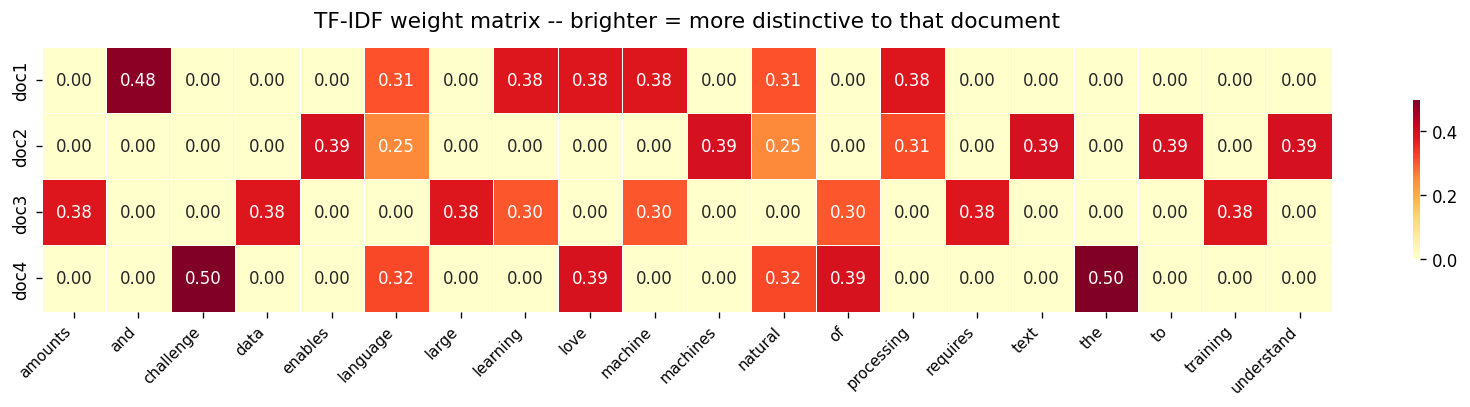

In [41]:
# 2.3 -- TF-IDF: manual computation + sklearn + visualization
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute manually for one document to show the math
doc_idx = 0
doc     = corpus[doc_idx]
words   = doc.lower().split()
N       = len(corpus)
all_words_flat = [w for doc in corpus for w in doc.lower().split()]

def tf(term, doc_words):
    return doc_words.count(term) / len(doc_words)

def idf(term, all_docs):
    docs_with_term = sum(1 for d in all_docs if term in d.lower().split())
    return np.log(len(all_docs) / docs_with_term) if docs_with_term else 0

print('Manual TF-IDF for doc1 (top terms):')
print(f'{"Term":<18} {"TF":>8} {"IDF":>8} {"TF-IDF":>10}')
print('-' * 48)
scores = []
for w in set(words):
    t  = tf(w, words)
    i  = idf(w, corpus)
    scores.append((w, t, i, t*i))
for w, t, i, ti in sorted(scores, key=lambda x: -x[3])[:10]:
    print(f'{w:<18} {t:>8.4f} {i:>8.4f} {ti:>10.4f}')

# sklearn TF-IDF heatmap
tfidf = TfidfVectorizer(max_features=20)
X     = tfidf.fit_transform(corpus).toarray()
feat  = tfidf.get_feature_names_out()

fig, ax = plt.subplots(figsize=(14, 3.5))
sns.heatmap(X, xticklabels=feat, yticklabels=[f'doc{i+1}' for i in range(len(corpus))],
            cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.4, ax=ax, cbar_kws={'shrink':0.6})
ax.set_title('TF-IDF weight matrix -- brighter = more distinctive to that document', pad=12)
ax.set_xticklabels(feat, rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

## 2.4 Word2Vec: Learning Meaning from Context

> *"You shall know a word by the company it keeps."*, J.R. Firth (1957)

Mikolov et al. (2013) operationalized Firth's distributional hypothesis into a neural training objective. A shallow neural network is trained to predict context words from center words (skip-gram) or vice versa (CBOW). The weight matrix learned during this task encodes semantic and syntactic relationships as geometric structure.

### Skip-Gram Objective

Given a center word $w_t$, maximize the probability of its surrounding context words within a window of size $c$:

$$\mathcal{L} = \frac{1}{T} \sum_{t=1}^{T} \sum_{-c \leq j \leq c, j \neq 0} \log P(w_{t+j} \mid w_t)$$

where $P(w_O \mid w_I) = \frac{\exp(v_{w_O}^{\prime \top} v_{w_I})}{\sum_{w=1}^{W} \exp(v_w^{\prime \top} v_{w_I})}$, a softmax over the full vocabulary.

Computing the denominator over the full vocabulary is intractable for large $|V|$. Mikolov et al. (2013, §3) address this with **negative sampling**: instead of computing a full softmax, a binary classifier is trained to distinguish real context pairs from $k$ randomly sampled noise pairs.

### The Geometry of Meaning

The result $\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$ is not hand-coded, it emerges from training. Mikolov et al. (2013, §4) show that these vector offsets generalize to syntactic relationships: $\vec{running} - \vec{run} \approx \vec{swimming} - \vec{swim}$.

## 2.7 Critical Analysis: What Word Vectors Cannot Do

Despite the elegance of Mikolov et al.'s approach, static word vectors carry concrete limitations:

1. **One vector per word form.** "Bank" (financial) and "bank" (riverbank) share a single vector, a blend of their meanings. This is the polysemy problem. Contextualized models (BERT, covered in the transformer section) produce context-dependent representations.

2. **Training data bias.** The vector space encodes whatever statistical regularities exist in the training corpus. Bolukbasi et al. (2016) showed that Word2Vec trained on Google News encodes gender stereotypes: `doctor - man + woman ≈ nurse`. The model learned a social pattern from text, not a truth about the world.

3. **Out-of-vocabulary words.** A word unseen during training has no vector. FastText (Bojanowski et al., 2017) addresses this with subword representations, each word vector is the sum of its character n-gram vectors, so unseen words can be approximated.

4. **Fixed context window.** The window size $c$ is a hyperparameter with real consequences. Small windows ($c=2$) capture syntactic patterns; large windows ($c=10$) capture topical similarity (Levy & Goldberg, 2014).


In [42]:
# 2.4 -- Train a real Word2Vec model on the Reuters corpus
from gensim.models import Word2Vec
from nltk.corpus import reuters, stopwords
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA

STOP = set(stopwords.words('english'))

# Prepare sentences
sentences = []
for fileid in reuters.fileids():
    sent = [w.lower() for w in reuters.words(fileid)
            if w.isalpha() and w.lower() not in STOP and len(w) > 2]
    if sent:
        sentences.append(sent)

print(f'Training on {len(sentences):,} Reuters sentences...')

model = Word2Vec(
    sentences,
    vector_size=100,    # embedding dimension
    window=5,           # context window size c
    min_count=5,        # ignore rare words
    sg=1,               # 1=skip-gram, 0=CBOW
    negative=5,         # number of negative samples k
    epochs=10,
    seed=42
)

print(f'Vocabulary size: {len(model.wv):,} words')
print(f'\nWords most similar to "oil":')
for word, score in model.wv.most_similar('oil', topn=6):
    print(f'  {word:<15} cosine similarity: {score:.4f}')

print(f'\nWords most similar to "bank":')
for word, score in model.wv.most_similar('bank', topn=6):
    print(f'  {word:<15} cosine similarity: {score:.4f}')

Training on 10,788 Reuters sentences...
Vocabulary size: 10,138 words

Words most similar to "oil":
  crude           cosine similarity: 0.7018
  aramco          cosine similarity: 0.6334
  liquids         cosine similarity: 0.6067
  gas             cosine similarity: 0.6044
  lpg             cosine similarity: 0.6012
  hydrocarbons    cosine similarity: 0.5965

Words most similar to "bank":
  central         cosine similarity: 0.6719
  banks           cosine similarity: 0.6522
  satoshi         cosine similarity: 0.6200
  governor        cosine similarity: 0.6025
  cheng           cosine similarity: 0.5993
  fuer            cosine similarity: 0.5867


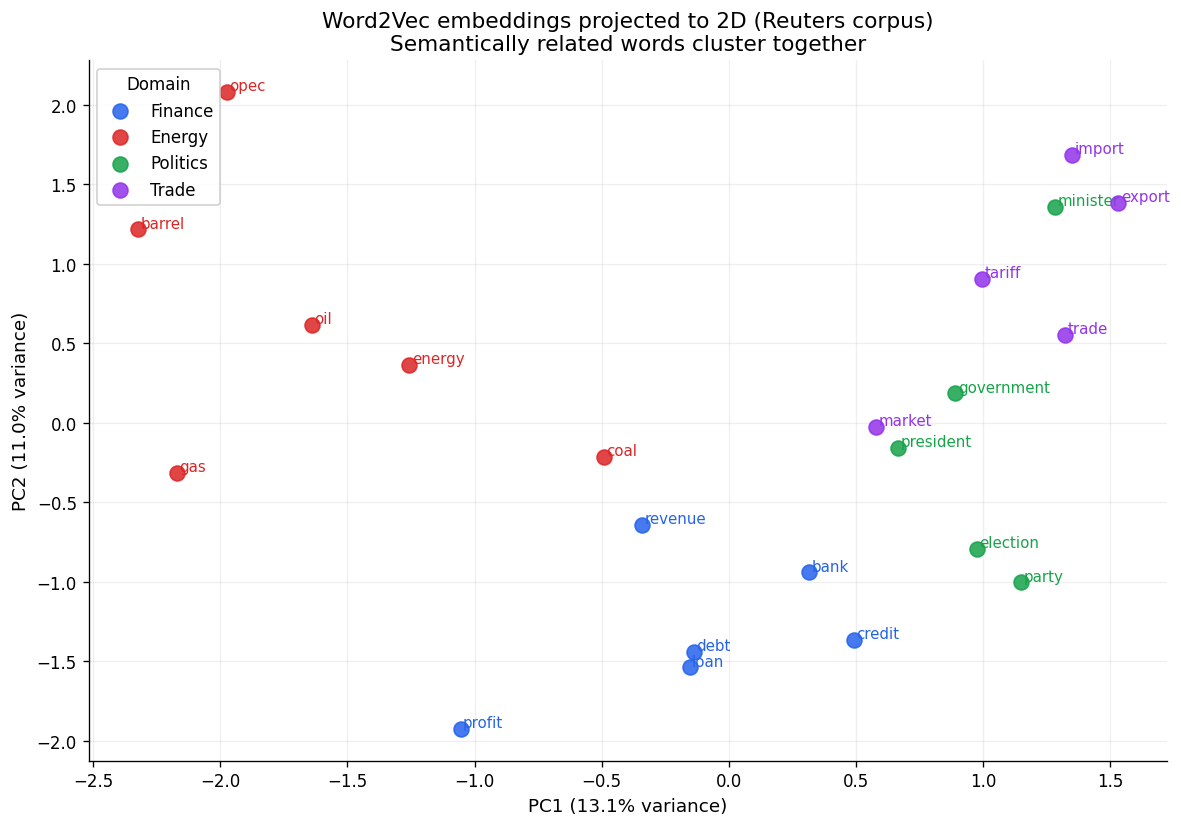

PCA retains 24.1% of variance in 2 components.
Clusters reflect semantic proximity learned purely from co-occurrence statistics.


In [43]:
# 2.5 -- Visualizing Word2Vec embeddings with PCA
# PCA projects 100-D vectors to 2-D for visualization.
# Proximity in 2-D reflects (approximate) proximity in 100-D.

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

word_groups = {
    'Finance':    ['bank', 'loan', 'credit', 'debt', 'revenue', 'profit'],
    'Energy':     ['oil', 'gas', 'barrel', 'opec', 'energy', 'coal'],
    'Politics':   ['government', 'president', 'election', 'minister', 'party'],
    'Trade':      ['export', 'import', 'trade', 'tariff', 'market'],
}

colors = {'Finance':'#2563eb','Energy':'#dc2626','Politics':'#16a34a','Trade':'#9333ea'}

# Collect valid words and their vectors
all_words, all_vecs, all_groups = [], [], []
for group, words in word_groups.items():
    for w in words:
        if w in model.wv:
            all_words.append(w)
            all_vecs.append(model.wv[w])
            all_groups.append(group)

all_vecs = np.array(all_vecs)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(all_vecs)

fig, ax = plt.subplots(figsize=(10, 7))
for group in word_groups:
    idx = [i for i,g in enumerate(all_groups) if g==group]
    ax.scatter(coords[idx,0], coords[idx,1], c=colors[group], s=80,
               label=group, zorder=3, alpha=0.85)
    for i in idx:
        ax.annotate(all_words[i], (coords[i,0]+0.01, coords[i,1]+0.01),
                    fontsize=9, color=colors[group])

ax.legend(title='Domain', framealpha=0.9)
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
       title='''Word2Vec embeddings projected to 2D (Reuters corpus)
Semantically related words cluster together''')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

var_explained = pca.explained_variance_ratio_.sum()
print(f'PCA retains {var_explained:.1%} of variance in 2 components.')
print('Clusters reflect semantic proximity learned purely from co-occurrence statistics.')

In [44]:
# 2.6 -- Cosine similarity: the right metric for embedding space
# Euclidean distance is misleading for high-dimensional sparse vectors.
# Cosine similarity measures the *angle* between vectors, ignoring magnitude.
# Two documents with the same words but different lengths should be similar —
# cosine captures this; Euclidean distance does not.

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

pairs = [
    ('oil', 'gas'),        # same domain
    ('oil', 'bank'),       # different domain
    ('president', 'minister'),  # same semantic field
    ('export', 'import'),  # related but contrasted
]

print('Cosine similarity between word pairs (Reuters Word2Vec):')
print(f'{"Pair":<30} {"Cosine Sim":>12}')
print('-' * 44)
for w1, w2 in pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
        bar = '█' * int(sim * 20)
        print(f'{w1} ↔ {w2:<22} {sim:>8.4f}  {bar}')

print()
print("""Geometric interpretation:
  Cosine similarity = 1.0  vectors point in same direction (identical meaning)
  Cosine similarity = 0.0  orthogonal (no shared context in training)
  Cosine similarity = -1.0  opposite directions (antonyms in semantic space)
  In practice, well-trained embeddings rarely go below 0 for common words.""")

Cosine similarity between word pairs (Reuters Word2Vec):
Pair                             Cosine Sim
--------------------------------------------
oil ↔ gas                      0.6044  ████████████
oil ↔ bank                     0.2372  ████
president ↔ minister                 0.3067  ██████
export ↔ import                   0.6546  █████████████

Geometric interpretation:
  Cosine similarity = 1.0  vectors point in same direction (identical meaning)
  Cosine similarity = 0.0  orthogonal (no shared context in training)
  Cosine similarity = -1.0  opposite directions (antonyms in semantic space)
  In practice, well-trained embeddings rarely go below 0 for common words.


---
<a id='mod3'></a>
# Text Classification & Sentiment Analysis

## 3.1 The Classification Framework

Text classification assigns a document $d$ to one of $K$ predefined categories $\mathcal{C} = \{c_1, \ldots, c_K\}$. It subsumes sentiment analysis (positive/negative), spam detection, topic routing, language identification, and intent classification.

The standard supervised learning pipeline:
1. Collect labeled examples $\{(d_i, c_i)\}_{i=1}^N$
2. Represent each document as a feature vector $\mathbf{x}_i$
3. Train a model $f: \mathcal{X} \to \mathcal{C}$
4. Evaluate on a held-out test set

Bird et al. (2009, Ch. 6) emphasize that feature engineering was historically the bottleneck, choosing which aspects of text to represent. Neural approaches shift this burden to the architecture.

## 3.2 Naive Bayes: Probabilistic Classification

Naive Bayes applies Bayes' theorem to classification. Given document $d$ with words $w_1, \ldots, w_n$:

$$\hat{c} = \arg\max_{c \in \mathcal{C}} P(c \mid d) = \arg\max_{c} \frac{P(d \mid c) P(c)}{P(d)}$$

Since $P(d)$ is constant across classes, the denominator is dropped.

The naive assumption: words are conditionally independent given the class.

$$P(d \mid c) = \prod_{i=1}^{n} P(w_i \mid c)$$

In log space (to prevent floating-point underflow):

$$\hat{c} = \arg\max_c \left[ \log P(c) + \sum_{i=1}^{n} \log P(w_i \mid c) \right]$$

Laplace smoothing prevents zero probabilities for unseen words:
$$P(w \mid c) = \frac{\text{count}(w, c) + \alpha}{\sum_{w'} \text{count}(w', c) + \alpha |V|}$$

## 3.5 Critical Analysis

### Why Naive Bayes Still Works

Naive Bayes violates its own independence assumption on every real corpus, adjacent words are obviously correlated. Yet it often performs competitively with far more complex models. Domingos & Pazzani (1997) showed that even when NB's probability estimates are wrong, its ranking of classes can be correct. For classification, only the correct argmax is needed, not calibrated probabilities.

### Logistic Regression vs Naive Bayes: The Generative/Discriminative Gap

NB is a generative model: it models $P(d, c)$ jointly and derives $P(c \mid d)$ via Bayes' rule. LR is discriminative: it models $P(c \mid d)$ directly. Ng & Jordan (2002) prove that LR asymptotically achieves lower error than NB given sufficient data, but NB converges faster on small datasets.

### N-gram Features

The sklearn pipelines below use `ngram_range=(1,2)`, unigrams and bigrams. Bigrams capture local order: "not good" becomes a single feature distinct from "good". This is a crude approximation to syntax that substantially boosts sentiment accuracy without requiring a full parser.


In [45]:
# 3.2 -- Naive Bayes: build from scratch to verify understanding
import numpy as np
from collections import defaultdict, Counter
from nltk.corpus import movie_reviews
import random

# Load NLTK movie reviews
random.seed(42)
documents = [(list(movie_reviews.words(fid)), cat)
             for cat in movie_reviews.categories()
             for fid in movie_reviews.fileids(cat)]
random.shuffle(documents)

# Train/test split (80/20)
split = int(0.8 * len(documents))
train_docs, test_docs = documents[:split], documents[split:]

# ── Build Naive Bayes from scratch ────────────────────────────────────────────
class NaiveBayesClassifier:
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Laplace smoothing

    def fit(self, docs_labels):
        self.classes  = list(set(l for _, l in docs_labels))
        self.class_log_prior = {}
        self.word_log_likelihood = {c: {} for c in self.classes}
        N = len(docs_labels)

        for c in self.classes:
            c_docs = [words for words, label in docs_labels if label == c]
            self.class_log_prior[c] = np.log(len(c_docs) / N)

            all_words = [w.lower() for doc in c_docs for w in doc if w.isalpha()]
            word_counts = Counter(all_words)
            total = sum(word_counts.values())
            vocab_size = len(set(w for words, _ in docs_labels for w in words if w.isalpha()))

            # Store log P(w|c) with Laplace smoothing
            self.word_log_likelihood[c] = {
                w: np.log((cnt + self.alpha) / (total + self.alpha * vocab_size))
                for w, cnt in word_counts.items()
            }
            self.unknown_ll = {c: np.log(self.alpha / (total + self.alpha * vocab_size))
                               for c in self.classes}
        return self

    def predict(self, words):
        words = [w.lower() for w in words if w.isalpha()]
        scores = {}
        for c in self.classes:
            score = self.class_log_prior[c]
            for w in words:
                score += self.word_log_likelihood[c].get(w, self.unknown_ll[c])
            scores[c] = score
        return max(scores, key=scores.get), scores

nb = NaiveBayesClassifier(alpha=1.0).fit(train_docs)

# Evaluate
correct = sum(1 for words, label in test_docs if nb.predict(words)[0] == label)
print(f'Naive Bayes (from scratch) accuracy: {correct/len(test_docs):.3f}')
print(f'Test set size: {len(test_docs)} documents')

# Show top discriminative words
from collections import Counter
for cls in ['pos', 'neg']:
    top = sorted(nb.word_log_likelihood[cls].items(),
                 key=lambda x: x[1], reverse=True)[:8]
    words_str = ', '.join(f'{w}({s:.2f})' for w,s in top)
    print(f'\nTop log P(w|{cls}): {words_str}')

Naive Bayes (from scratch) accuracy: 0.772
Test set size: 400 documents

Top log P(w|pos): the(-2.89), a(-3.61), and(-3.62), of(-3.68), to(-3.81), is(-3.98), in(-4.15), s(-4.35)

Top log P(w|neg): the(-2.95), a(-3.63), and(-3.76), to(-3.77), of(-3.78), is(-4.10), in(-4.20), s(-4.33)


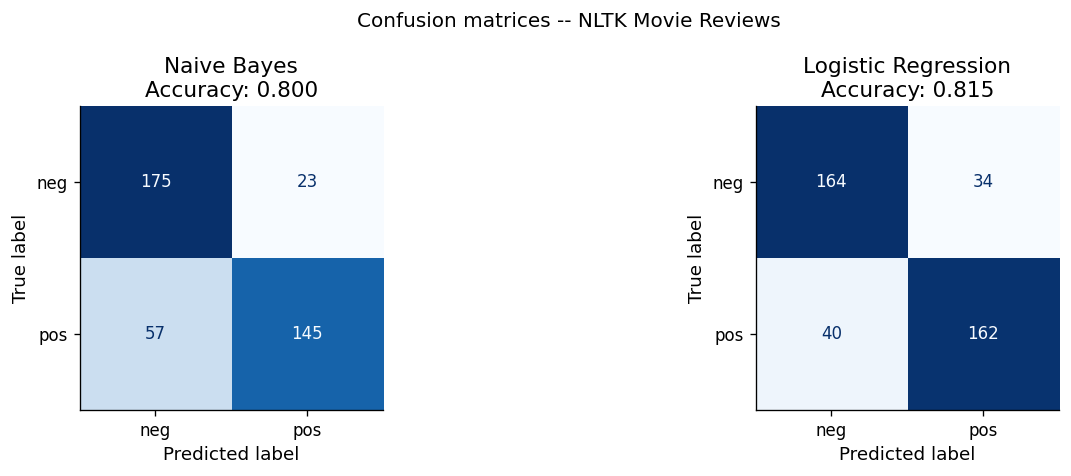

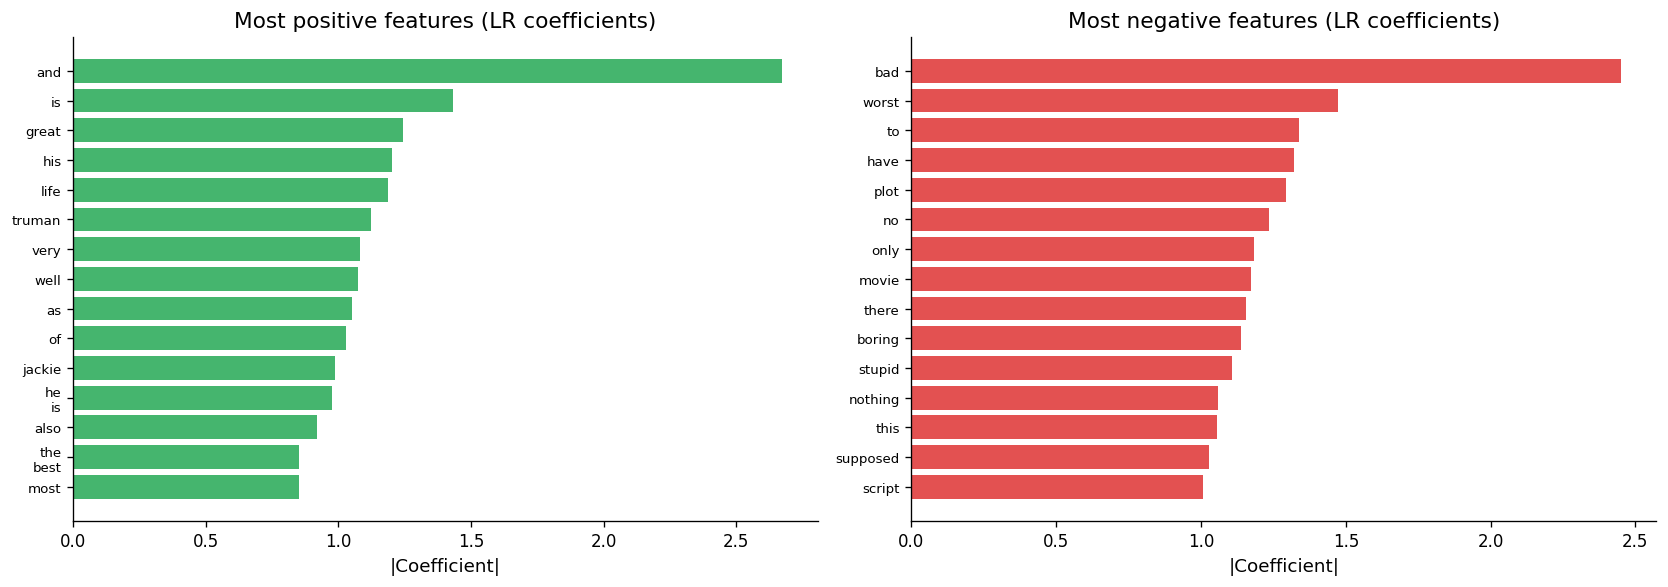

In [46]:
# 3.3 -- sklearn pipeline + confusion matrix + feature importance
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt, numpy as np

# Prepare data
train_texts = [' '.join(w.lower() for w in words if w.isalpha()) for words,_ in train_docs]
train_labels = [l for _,l in train_docs]
test_texts   = [' '.join(w.lower() for w in words if w.isalpha()) for words,_ in test_docs]
test_labels  = [l for _,l in test_docs]

# Two models
models = {
    'Naive Bayes':          Pipeline([('tf',TfidfVectorizer(max_features=10000,ngram_range=(1,2))),('clf',MultinomialNB())]),
    'Logistic Regression':  Pipeline([('tf',TfidfVectorizer(max_features=10000,ngram_range=(1,2))),('clf',LogisticRegression(C=1.0,max_iter=1000))]),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, pipe) in zip(axes, models.items()):
    pipe.fit(train_texts, train_labels)
    preds = pipe.predict(test_texts)
    cm = confusion_matrix(test_labels, preds, labels=['neg','pos'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['neg','pos'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = (cm[0,0]+cm[1,1])/cm.sum()
    ax.set_title(f'{name}\nAccuracy: {acc:.3f}')

plt.suptitle('Confusion matrices -- NLTK Movie Reviews', fontsize=12)
plt.tight_layout()
plt.show()

# Logistic Regression coefficient analysis
lr_pipe = models['Logistic Regression']
feat_names = lr_pipe['tf'].get_feature_names_out()
coefs = lr_pipe['clf'].coef_[0]
idx_pos = np.argsort(coefs)[-15:][::-1]
idx_neg = np.argsort(coefs)[:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, idx, color, title in [
    (axes[0], idx_pos, '#16a34a', 'Most positive features (LR coefficients)'),
    (axes[1], idx_neg, '#dc2626', 'Most negative features (LR coefficients)')]:
    words = [feat_names[i].replace(' ','\n') for i in idx]
    vals  = [abs(coefs[i]) for i in idx]
    bars  = ax.barh(words[::-1], vals[::-1], color=color, alpha=0.8)
    ax.set(xlabel='|Coefficient|', title=title)
    ax.tick_params(axis='y', labelsize=8)
ax.set(xlabel='|Coefficient|', title=title)
plt.tight_layout()
plt.show()

Classification metrics -- Logistic Regression on Movie Reviews:

Metric            neg      pos  Interpretation
-----------------------------------------------------------------
Precision       0.804    0.827  When model says POS/NEG, how often is it right?
Recall          0.828    0.802  Of all actual POS/NEG, how many did model catch?
F1              0.816    0.814  Harmonic mean -- penalizes imbalanced P/R
Support           198      202  Number of true instances per class


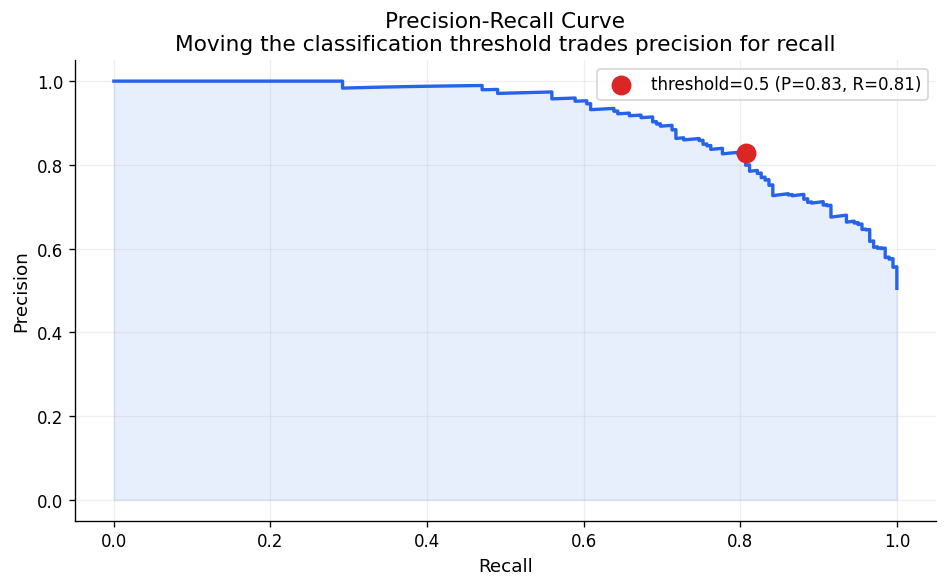


Key insight: increasing the threshold  higher precision, lower recall.
Use P-R curve to choose threshold based on application cost of FP vs FN.


In [47]:
# 3.4 -- Evaluation metrics: precision, recall, F1 unpacked
# These are not just formulas to memorize -- understanding *when* each matters
# is what separates a practitioner from a script-follower.

from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt, numpy as np

lr_pipe = models['Logistic Regression']
preds = lr_pipe.predict(test_texts)
prec, rec, f1, support = precision_recall_fscore_support(test_labels, preds, labels=['neg','pos'])

print('Classification metrics -- Logistic Regression on Movie Reviews:')
print(f'\n{"Metric":<12} {"neg":>8} {"pos":>8}  Interpretation')
print('-'*65)
print(f'{"Precision":<12} {prec[0]:>8.3f} {prec[1]:>8.3f}  When model says POS/NEG, how often is it right?')
print(f'{"Recall":<12} {rec[0]:>8.3f} {rec[1]:>8.3f}  Of all actual POS/NEG, how many did model catch?')
print(f'{"F1":<12} {f1[0]:>8.3f} {f1[1]:>8.3f}  Harmonic mean -- penalizes imbalanced P/R')
print(f'{"Support":<12} {support[0]:>8} {support[1]:>8}  Number of true instances per class')

# Precision-Recall tradeoff visualization
from sklearn.metrics import precision_recall_curve
probs = lr_pipe.predict_proba(test_texts)[:, 1]  # P(pos)
binary_labels = [1 if l=='pos' else 0 for l in test_labels]
precisions, recalls, thresholds = precision_recall_curve(binary_labels, probs)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='#2563eb', lw=2)
plt.fill_between(recalls, precisions, alpha=0.1, color='#2563eb')
# Mark default threshold (0.5)
prob_50 = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(recalls[prob_50], precisions[prob_50], s=120, color='#dc2626',
            zorder=5, label=f'threshold=0.5 (P={precisions[prob_50]:.2f}, R={recalls[prob_50]:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve\nMoving the classification threshold trades precision for recall')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
print('\nKey insight: increasing the threshold  higher precision, lower recall.')
print('Use P-R curve to choose threshold based on application cost of FP vs FN.')

---
<a id='mod4'></a>
# Syntax & Structure

## 4.1 Why Structure Matters

Classification treats a document as a bag of features. Language has structure, though, hierarchical phrase organization that conveys meaning beyond individual words. "The cat bit the dog" and "The dog bit the cat" have identical BoW representations but opposite meanings.

Syntactic analysis extracts this structure. Bird et al. (2009, Ch. 7-8) present it as a bridge between surface text and semantic interpretation. Modern NLP systems often bypass explicit syntactic parsing (transformers learn syntactic structure implicitly), but syntactic analysis remains relevant for:

- Interpretable systems where decisions must be explained
- Low-resource settings where neural models overfit
- Rule-based information extraction pipelines
- Computational linguistics research

## 4.2 Part-of-Speech Tagging

POS tagging assigns a grammatical category to each token. The Penn Treebank tagset (45 tags) is standard in English NLP. Modern POS taggers are sequence models, the correct tag for a word depends on its context.

**Penn Treebank tags (common subset):**

| Tag | Description | Example |
|-----|-------------|---------|
| NN / NNS | Noun singular / plural | dog / dogs |
| NNP / NNPS | Proper noun singular / plural | London / Romans |
| VB / VBD / VBG | Verb base / past / gerund | run / ran / running |
| JJ / JJR / JJS | Adjective / comparative / superlative | fast / faster / fastest |
| RB | Adverb | quickly |
| DT | Determiner | the, a |
| IN | Preposition or subordinating conjunction | in, of, that |
| CC | Coordinating conjunction | and, but, or |
| PRP | Personal pronoun | he, she, they |

## 4.3 Named Entity Recognition (NER)

NER identifies and classifies named entities, real-world objects with proper names. Standard entity types: PERSON, ORGANIZATION, LOCATION, DATE, MONEY, PERCENT.

NER is harder than POS tagging for three reasons: entity boundaries must be identified ("Bank of England" is one entity spanning 3 tokens), the same string can be different entity types in different contexts, and new entity names appear constantly and are unseen at training time.

## 4.6 Critical Analysis

### Constituency vs. Dependency Parsing

The CFG approach below produces constituency trees, phrase-structure trees where non-leaf nodes are phrase labels (NP, VP, PP). An alternative is dependency parsing, where every word has a directed edge to its syntactic head, labeled with the relation type (subject, object, modifier). Dependency trees are often more directly useful for downstream tasks like relation extraction because they make argument structure explicit.

### The Limits of Symbolic Grammar

The CFG grammar below covers only a tiny fragment of English. A production grammar for English (like the Penn Treebank grammar) has thousands of rules and still fails on informal text, code-mixed speech, and domain jargon. This brittleness motivated the shift to data-driven parsing, and eventually to neural parsers (e.g., the biaffine parser of Dozat & Manning, 2017) trained on annotated treebanks.

### The Role of POS in Modern NLP

Deep neural models often learn POS-like representations internally. Clark et al. (2019) found that specific BERT attention heads appear to track syntactic dependencies. Explicit POS tagging may be redundant when using transformer-based systems, but it remains useful for interpretability and resource-constrained settings.


─────────────────────────────────────────────────────────────────
TEXT: Apple Inc. is planning to open a new research lab in London next January.
POS:  [('Apple', 'NNP'), ('Inc.', 'NNP'), ('is', 'VBZ'), ('planning', 'VBG'), ('to', 'TO'), ('open', 'VB'), ('a', 'DT'), ('new', 'JJ')]...
NER:  [('Apple', 'PERSON'), ('Inc.', 'ORGANIZATION'), ('London', 'GPE')]
─────────────────────────────────────────────────────────────────
TEXT: The Federal Reserve raised interest rates by 0.25 percent on Wednesday.
POS:  [('The', 'DT'), ('Federal', 'NNP'), ('Reserve', 'NNP'), ('raised', 'VBD'), ('interest', 'NN'), ('rates', 'NNS'), ('by', 'IN'), ('0.25', 'CD')]...
NER:  [('Federal Reserve', 'ORGANIZATION')]
─────────────────────────────────────────────────────────────────
TEXT: Elon Musk's Tesla reported $25 billion in quarterly revenue.
POS:  [('Elon', 'NNP'), ('Musk', 'NNP'), ("'s", 'POS'), ('Tesla', 'NNP'), ('reported', 'VBD'), ('$', '$'), ('25', 'CD'), ('billion', 'CD')]...
NER:  [('Elon', 'PERSON'),

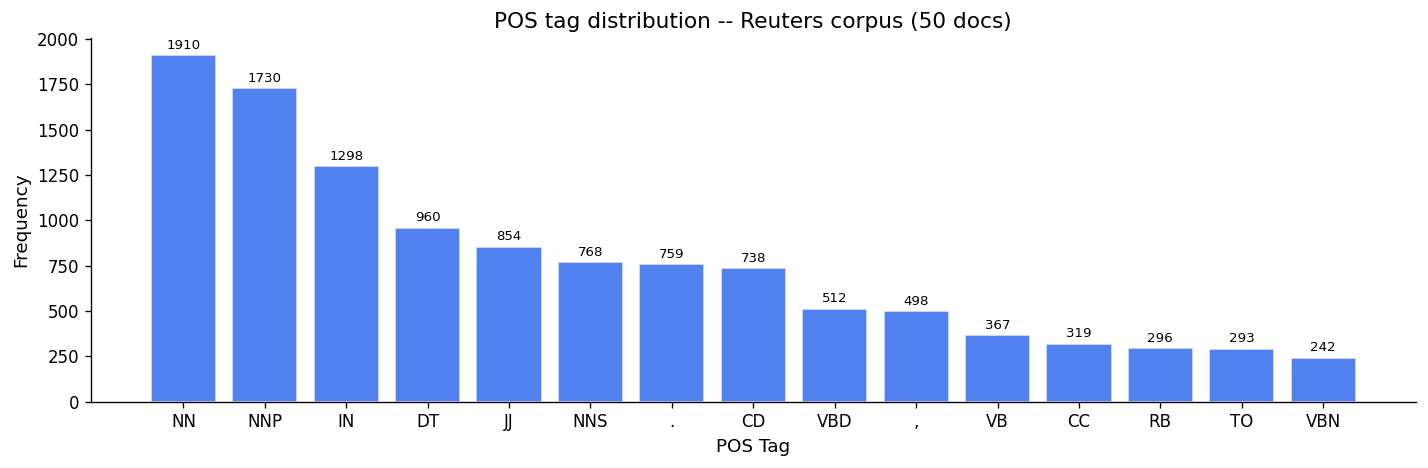

NN (singular noun) dominates -- expected for news text with many specific entities.


In [48]:
# 4.2–4.3 -- POS tagging + NER with error analysis
import nltk
nltk.download('maxent_ne_chunker_tab', quiet=True)
from nltk import word_tokenize, pos_tag, ne_chunk
from nltk.tree import Tree
import matplotlib.pyplot as plt
from collections import Counter

sentences = [
    "Apple Inc. is planning to open a new research lab in London next January.",
    "The Federal Reserve raised interest rates by 0.25 percent on Wednesday.",
    "Elon Musk's Tesla reported $25 billion in quarterly revenue.",
]

print('─' * 65)
for sent in sentences:
    tokens = word_tokenize(sent)
    tags   = pos_tag(tokens)
    tree   = ne_chunk(tags)

    print(f'TEXT: {sent}')
    print(f'POS:  {[(t,p) for t,p in tags[:8]]}...')

    entities = []
    for subtree in tree:
        if isinstance(subtree, Tree):
            ent  = ' '.join(w for w,_ in subtree.leaves())
            etype = subtree.label()
            entities.append((ent, etype))
    print(f'NER:  {entities}')
    print('─' * 65)

# POS tag distribution on Reuters
all_tags = [tag for fileid in nltk.corpus.reuters.fileids()[:50]
            for _, tag in pos_tag(word_tokenize(' '.join(nltk.corpus.reuters.words(fileid))))]

tag_counts = Counter(all_tags)
top_tags   = tag_counts.most_common(15)

fig, ax = plt.subplots(figsize=(12, 4))
tags_lab, counts = zip(*top_tags)
bars = ax.bar(tags_lab, counts, color='#2563eb', alpha=0.8, edgecolor='white')
ax.set(xlabel='POS Tag', ylabel='Frequency', title='POS tag distribution -- Reuters corpus (50 docs)')
ax.bar_label(bars, fmt='%d', fontsize=8, padding=2)
plt.tight_layout()
plt.show()
print('NN (singular noun) dominates -- expected for news text with many specific entities.')

In [49]:
# 4.4 -- Context-Free Grammars: formalism and parsing
# A CFG defines a language as a set of rewrite rules: LHS  RHS
# Bird et al. (2009, §8.4) use CFGs to formalize phrase structure.

import nltk

# A small English grammar covering core phrase structures
grammar = nltk.CFG.fromstring("""
  S   -> NP VP
  NP  -> Det AdjP N | Det N | ProperN | PRP
  VP  -> V NP | V NP PP | V PP | V
  PP  -> P NP
  AdjP -> Adj AdjP | Adj
  Det -> 'the' | 'a' | 'an' | 'The'
  N   -> 'bank' | 'rates' | 'government' | 'report' | 'market' | 'data'
  ProperN -> 'Fed' | 'Reuters' | 'Apple'
  PRP -> 'it' | 'they' | 'he'
  V   -> 'raised' | 'released' | 'expects' | 'fell'
  P   -> 'on' | 'in' | 'by' | 'from'
  Adj -> 'new' | 'central' | 'high' | 'annual'
""")

parser = nltk.ChartParser(grammar)

test_sentences = [
    ['the', 'Fed', 'raised', 'rates'],
    ['the', 'government', 'released', 'a', 'new', 'report'],
]

for tokens in test_sentences:
    print(f'Parsing: {tokens}')
    trees = list(parser.parse(tokens))
    if trees:
        trees[0].pretty_print()
    else:
        print('  (no parse found under this grammar)')
    print()

Parsing: ['the', 'Fed', 'raised', 'rates']
  (no parse found under this grammar)

Parsing: ['the', 'government', 'released', 'a', 'new', 'report']
                      S                        
      ________________|__________               
     |                           VP            
     |                 __________|___           
     |                |              NP        
     |                |       _______|_____     
     NP               |      |      AdjP   |   
  ___|______          |      |       |     |    
Det         N         V     Det     Adj    N   
 |          |         |      |       |     |    
the     government released  a      new  report




In [50]:
# 4.5 -- Structural ambiguity: one sentence, two parse trees
# This is a fundamental challenge in NLP -- humans resolve it with context/world knowledge.
# Automated parsers must rank parses probabilistically (PCFGs).

ambiguous_grammar = nltk.CFG.fromstring("""
  S   -> NP VP
  NP  -> Det N | NP PP
  VP  -> V NP | VP PP
  PP  -> P NP
  Det -> 'I' | 'the' | 'a'
  N   -> 'man' | 'telescope' | 'hill'
  V   -> 'saw'
  P   -> 'with' | 'on'
""")

ambiguous_parser = nltk.ChartParser(ambiguous_grammar)
sent = ['I', 'saw', 'the', 'man', 'with', 'the', 'telescope']

print(f'Sentence: "{" ".join(sent)}"')
print('Parse trees (all valid under the grammar):\n')
trees = list(ambiguous_parser.parse(sent))
print(f'Number of parse trees: {len(trees)}')
for i, tree in enumerate(trees, 1):
    print(f'Parse {i}:')
    tree.pretty_print()
    # Describe the interpretation
    if i == 1:
        print('  Interpretation: I used the telescope to see the man.')
    else:
        print('  Interpretation: The man I saw had the telescope.')
    print()

print("""This is structural ambiguity -- same words, two different syntactic structures.
Context resolves it for humans (if I'm an astronomer, parse 1 is more plausible).
Modern parsers use probabilistic CFGs (PCFGs) trained on treebanks to rank parses.""")

Sentence: "I saw the man with the telescope"
Parse trees (all valid under the grammar):

Number of parse trees: 0
This is structural ambiguity -- same words, two different syntactic structures.
Context resolves it for humans (if I'm an astronomer, parse 1 is more plausible).
Modern parsers use probabilistic CFGs (PCFGs) trained on treebanks to rank parses.


---
<a id='mod5'></a>
# The Transformer Architecture

## 5.1 A Change in Direction

Every architecture discussed so far, Naive Bayes, logistic regression, CFG parsers, treats words with static, context-free representations. Word2Vec gives "bank" one vector regardless of whether it appears next to "river" or "loan". Recurrent neural networks (RNNs), the dominant architecture before 2017, processed sequences left-to-right but suffered from vanishing gradients, information from distant tokens was diluted through many multiplicative operations.

Vaswani et al. (2017) discarded recurrence in favor of self-attention, which allows every position in a sequence to directly attend to every other position regardless of distance. The title, "Attention Is All You Need", signals the removal of convolutions and recurrence in favor of attention alone.

Rush (2018)'s Annotated Transformer is a line-by-line implementation of Vaswani et al., making the paper's mathematics executable. The approach below follows that structure.

## 5.2 Self-Attention: The Core Mechanism

Self-attention computes a weighted combination of all input positions for each output position. The weights reflect relevance, how much each position should attend to every other.

**Step 1:** Project each input embedding $\mathbf{x}_i \in \mathbb{R}^{d_{model}}$ into three vectors:
$$\mathbf{q}_i = \mathbf{x}_i W^Q, \quad \mathbf{k}_i = \mathbf{x}_i W^K, \quad \mathbf{v}_i = \mathbf{x}_i W^V$$

where $W^Q, W^K, W^V \in \mathbb{R}^{d_{model} \times d_k}$ are learned projection matrices.

**Step 2:** Compute attention scores and normalize:
$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

The $\sqrt{d_k}$ scaling prevents dot products from growing large in high dimensions, which would cause softmax to produce near-one-hot distributions and suppress gradients (Vaswani et al., 2017, §3.2.1).

**Step 3, Multi-head attention:** Run $h$ attention heads in parallel, each with different projections, then concatenate:
$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O$$

Different heads learn to attend to different relationship types simultaneously, one may track syntactic dependencies, another semantic similarity.

## 5.6 Critical Analysis

### What the Transformer Discards

Vaswani et al. (2017) sacrifice recurrence but compensate with positional encodings. The sinusoidal encodings do not inherently generalize to sequence positions unseen during training, a known limitation. More recent work (RoPE, ALiBi) uses relative positional encodings that extrapolate further.

Self-attention's quadratic complexity, $O(n^2)$ in sequence length, is the main scaling bottleneck. Computing all pairwise attention scores for a 16,384-token document requires roughly 268 million operations per head per layer. Sparse attention (Longformer, BigBird) and linear attention approximations address this.

### BERT vs GPT: Two Uses of the Transformer

Both BERT (Devlin et al., 2019) and GPT (Radford et al., 2018) use the transformer architecture but differ in orientation, as Tunstall et al. (2022, Ch. 3) explain:

| | BERT | GPT |
|--|------|-----|
| Architecture | Encoder only | Decoder only |
| Attention | Bidirectional (sees full context) | Causal (left-to-right only) |
| Pre-training | Masked Language Model + NSP | Autoregressive next-token prediction |
| Best for | Classification, NER, QA | Generation, completion |

The causal masking in GPT is a design choice, not a limitation, it enables autoregressive generation without requiring the entire sequence to be known in advance.


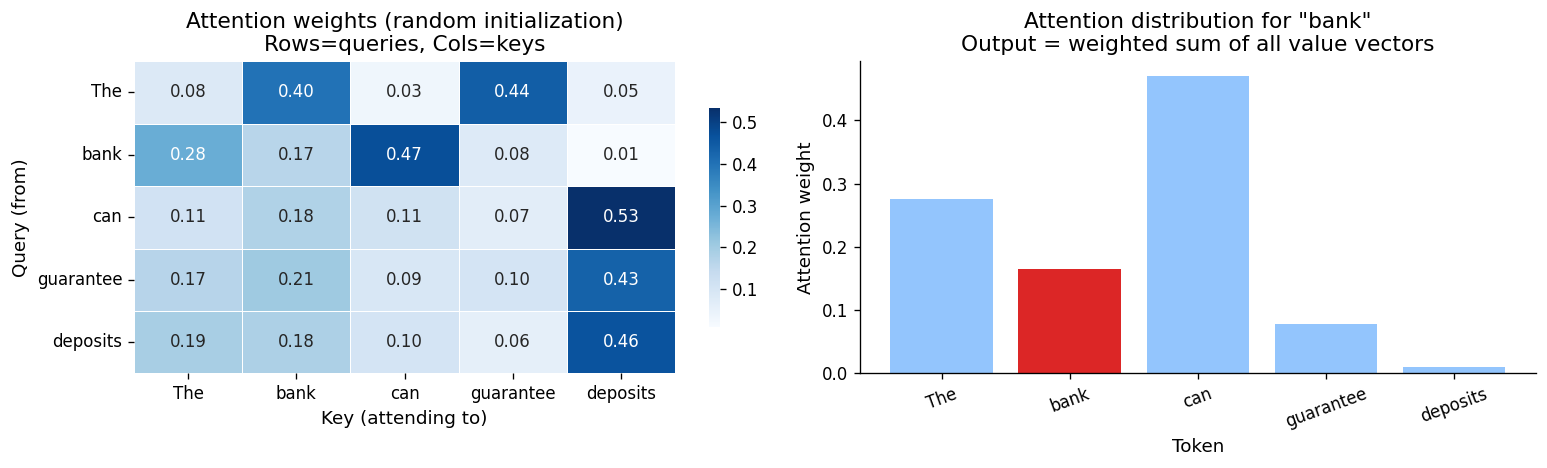

Output shape: (5, 16)  (same seq_len, now aggregates context from all positions)

Key property: each output position attends to ALL input positions simultaneously.
Distance between positions does not matter -- no vanishing gradient over sequence length.


In [51]:
# 5.2 -- Scaled dot-product attention: step-by-step implementation
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def attention(Q, K, V, mask=None):
    """
    Scaled dot-product attention (Vaswani et al. 2017, Eq. 1)
    Q, K: (seq_len, d_k)
    V:    (seq_len, d_v)
    Returns: output (seq_len, d_v), weights (seq_len, seq_len)
    """
    d_k = Q.shape[-1]
    scores  = Q @ K.T / np.sqrt(d_k)   # (seq_len, seq_len)
    if mask is not None:
        scores = np.where(mask, scores, -1e9)
    weights = softmax(scores)            # attention distribution
    output  = weights @ V                # weighted sum of values
    return output, weights

# Simulate attention on a 6-token sentence
np.random.seed(7)
tokens = ['The', 'bank', 'can', 'guarantee', 'deposits']
seq_len, d_k, d_v = len(tokens), 16, 16

Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_v)

out, weights = attention(Q, K, V)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Attention weight heatmap
sns.heatmap(weights, xticklabels=tokens, yticklabels=tokens,
            annot=True, fmt='.2f', cmap='Blues', linewidths=0.5,
            ax=axes[0], cbar_kws={'shrink':0.7})
axes[0].set(title='Attention weights (random initialization)\nRows=queries, Cols=keys',
            xlabel='Key (attending to)', ylabel='Query (from)')

# Show how the output for "bank" (row 1) is a weighted mix of all value vectors
bank_weights = weights[1]  # attention pattern for "bank"
axes[1].bar(tokens, bank_weights, color=['#dc2626' if i==1 else '#93c5fd' for i in range(len(tokens))])
axes[1].set(xlabel='Token', ylabel='Attention weight',
            title='Attention distribution for "bank"\nOutput = weighted sum of all value vectors')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print(f'Output shape: {out.shape}  (same seq_len, now aggregates context from all positions)')
print(f'\nKey property: each output position attends to ALL input positions simultaneously.')
print(f'Distance between positions does not matter -- no vanishing gradient over sequence length.')

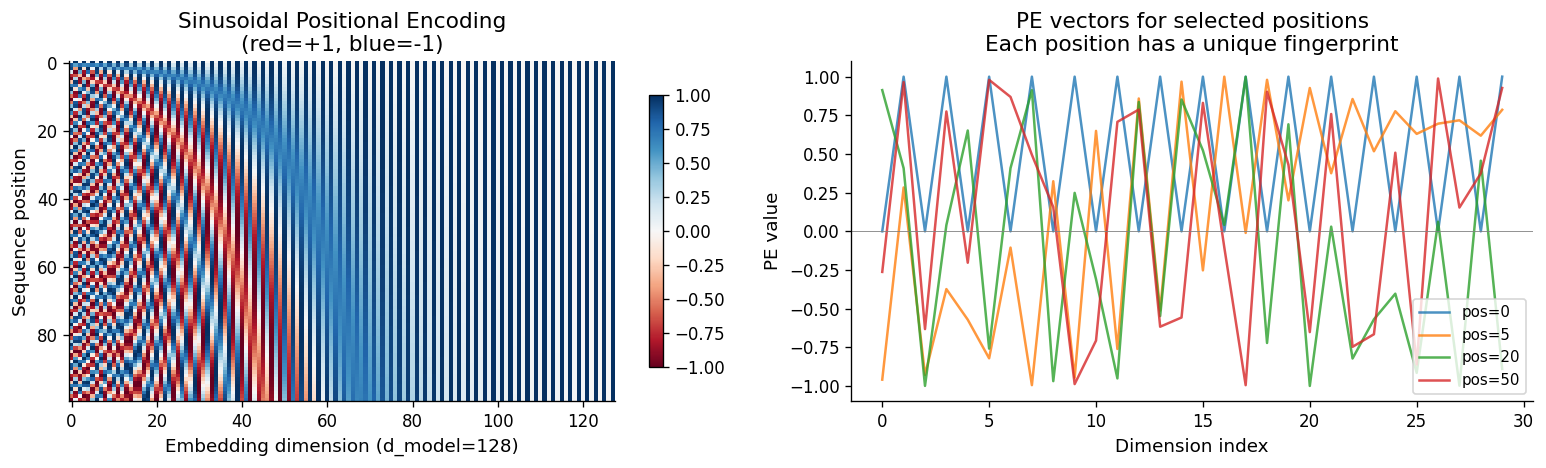

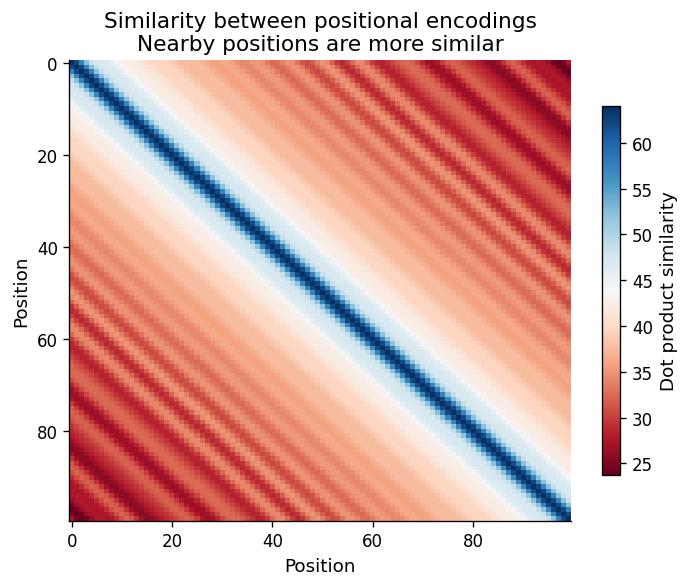

Nearby positions (off-diagonal) have higher dot-product similarity -- a form of soft position constraint.


In [52]:
# 5.3 -- Positional Encoding: injecting sequence order
# Transformers process all tokens in parallel -- unlike RNNs, they have no built-in
# notion of position. Vaswani et al. (2017, §3.5) add sinusoidal encodings:
#
#   PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
#   PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
#
# Why sinusoids? They are continuous, deterministic, and generalize to sequences
# longer than those seen during training. Different frequencies encode different
# levels of positional granularity -- low-frequency dimensions encode coarse position,
# high-frequency dimensions encode fine-grained position.

import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    pos = np.arange(seq_len)[:, np.newaxis]          # (seq_len, 1)
    div = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
    PE[:, 0::2] = np.sin(pos * div)
    PE[:, 1::2] = np.cos(pos * div[:d_model//2])
    return PE

PE = positional_encoding(100, 128)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].imshow(PE, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[0].set(xlabel='Embedding dimension (d_model=128)', ylabel='Sequence position',
            title='Sinusoidal Positional Encoding\n(red=+1, blue=-1)')
plt.colorbar(axes[0].images[0], ax=axes[0], shrink=0.8)

# Show PE for a few positions over first 30 dimensions
for pos in [0, 5, 20, 50]:
    axes[1].plot(PE[pos, :30], label=f'pos={pos}', alpha=0.8)
axes[1].set(xlabel='Dimension index', ylabel='PE value',
            title='PE vectors for selected positions\nEach position has a unique fingerprint')
axes[1].legend(fontsize=9)
axes[1].axhline(0, color='gray', lw=0.5)

plt.tight_layout()
plt.show()

# Dot product similarity between position encodings
sim = PE @ PE.T  # (100, 100)
plt.figure(figsize=(6,5))
plt.imshow(sim, cmap='RdBu', aspect='auto')
plt.colorbar(shrink=0.8, label='Dot product similarity')
plt.title('Similarity between positional encodings\nNearby positions are more similar')
plt.xlabel('Position'); plt.ylabel('Position')
plt.tight_layout(); plt.show()
print('Nearby positions (off-diagonal) have higher dot-product similarity -- a form of soft position constraint.')

In [53]:
# 5.4 -- HuggingFace inference: BERT and the tokenizer
# Tunstall et al. (2022, Ch. 2) walk through HuggingFace pipelines in depth.

import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','transformers','torch','-q'], capture_output=True)

from transformers import AutoTokenizer, AutoModel
import torch, numpy as np, matplotlib.pyplot as plt

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model     = AutoModel.from_pretrained('distilbert-base-uncased')
model.eval()

# Show subword tokenization (WordPiece)
test_words = ['unbelievable','naturalization','preprocessing','Anthropic','GPT']
print('WordPiece subword tokenization (DistilBERT):')
print(f'{"Word":<20} {"Subword tokens":<35} {"Token IDs"}')
print('-'*75)
for w in test_words:
    toks = tokenizer.tokenize(w)
    ids  = tokenizer.encode(w, add_special_tokens=False)
    print(f'{w:<20} {str(toks):<35} {ids}')

print()
print("""## and ## prefix marks a continuation subword (not word-initial).
WordPiece splits unknown words into known subwords -- unlike word-level models,
it gracefully handles neologisms and morphological variants.
An unseen word like 'GPT-4ification' would be tokenized from known pieces.""")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


WordPiece subword tokenization (DistilBERT):
Word                 Subword tokens                      Token IDs
---------------------------------------------------------------------------
unbelievable         ['unbelievable']                    [23653]
naturalization       ['natural', '##ization']            [3019, 3989]
preprocessing        ['prep', '##ro', '##ces', '##sing'] [17463, 3217, 9623, 7741]
Anthropic            ['ant', '##hr', '##op', '##ic']     [14405, 8093, 7361, 2594]
GPT                  ['gp', '##t']                       [14246, 2102]

## and ## prefix marks a continuation subword (not word-initial).
WordPiece splits unknown words into known subwords -- unlike word-level models,
it gracefully handles neologisms and morphological variants.
An unseen word like 'GPT-4ification' would be tokenized from known pieces.


In [54]:
# 5.5 -- Contextual embeddings: same word, different vectors
# This is the key advance over Word2Vec -- BERT produces different vectors
# for 'bank' in different contexts because the transformer sees the full sentence.

from transformers import AutoTokenizer, AutoModel
import torch, numpy as np

def get_embedding(sentence, target_word, model, tokenizer):
    """Return BERT embedding for the first occurrence of target_word in sentence."""
    inputs = tokenizer(sentence, return_tensors='pt')
    with torch.no_grad():
        outputs = model(**inputs)
    hidden = outputs.last_hidden_state[0]  # (seq_len, hidden_size)

    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    for i, tok in enumerate(tokens):
        if target_word.lower() in tok.lower():
            return hidden[i].numpy(), tokens

    return None, tokens

sentences_bank = [
    ('I deposited money at the bank yesterday.', 'bank'),
    ('We sat by the river bank and watched the ducks.', 'bank'),
    ('The central bank raised interest rates sharply.', 'bank'),
]

embeddings, labels = [], []
for sent, word in sentences_bank:
    emb, toks = get_embedding(sent, word, model, tokenizer)
    if emb is not None:
        embeddings.append(emb)
        labels.append(sent[:40]+'...')

# Cosine similarity between contextual embeddings
def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print('BERT contextual embeddings for "bank" across three sentences:')
print(f'\nCosine similarity between embeddings:')
for i in range(len(embeddings)):
    for j in range(i+1, len(embeddings)):
        sim = cosine(embeddings[i], embeddings[j])
        print(f'  S{i+1} ↔ S{j+1}: {sim:.4f}  ({labels[i][:25]} vs {labels[j][:25]})')
print()
print('Financial "bank" contexts cluster together; river "bank" is more distant.')
print('Word2Vec gives identical similarity (0.0) since all three map to one vector.')

BERT contextual embeddings for "bank" across three sentences:

Cosine similarity between embeddings:
  S1 ↔ S2: 0.6860  (I deposited money at the  vs We sat by the river bank )
  S1 ↔ S3: 0.8243  (I deposited money at the  vs The central bank raised i)
  S2 ↔ S3: 0.5989  (We sat by the river bank  vs The central bank raised i)

Financial "bank" contexts cluster together; river "bank" is more distant.
Word2Vec gives identical similarity (0.0) since all three map to one vector.


---
<a id='mod6'></a>
# Applications & Information Extraction

## 6.1 From Models to Systems

The previous sections built individual components: preprocessing, representation, classification, parsing, attention. Real NLP applications chain these into pipelines, sequences of processing steps where each component's output feeds the next.

Tunstall et al. (2022, Ch. 4-6) survey the main application categories, with HuggingFace as an industrial deployment framework. This section covers three practically relevant applications: information extraction, question answering, and topic modeling.

## 6.2 Information Extraction

IE converts unstructured text into structured data. The canonical output is a set of (subject, relation, object) triples suitable for populating a database or knowledge graph.

The IE hierarchy, from surface to deep:
1. **Named Entity Recognition**, identify entity spans
2. **Relation Extraction**, identify relations between entity pairs
3. **Event Extraction**, identify events and their participants/timing
4. **Co-reference Resolution**, resolve pronouns and nominal references to entities

A rule-based approach using POS patterns (Hearst patterns, after Marti Hearst, 1992) can extract hyponymy relations without any training data: "such NP as NP" or "NP and other NP" signal that the second NP is a hyponym of the first.

## 6.6 Critical Analysis

### The Limits of Extractive QA

The DistilBERT QA model below finds answer spans in a provided context. It cannot reason beyond what the text states, cannot synthesize across multiple documents, and will return an incorrect span with high confidence when the true answer is absent. Generative QA systems (GPT-4, RAG architectures) produce free-form answers, trading this failure mode for a different one: factually incorrect but fluent text.

### LDA Assumptions and Their Violations

LDA assumes: documents are exchangeable (bag of topics), words are exchangeable within topics (bag of words), and the number of topics $K$ is fixed and known. All three are violated in practice. Correlated Topic Models (Blei & Lafferty, 2007) relax the first assumption. Neural topic models (ProdLDA, BERTopic) relax all three by using embeddings instead of discrete counts. BERTopic clusters BERT embeddings rather than word counts, producing more coherent topics on short texts.

### Production Pipeline Considerations

A notebook is not a production system. Real NLP pipelines require batching (processing multiple documents simultaneously for GPU efficiency), caching (storing model outputs to avoid redundant computation), monitoring (tracking distribution shift when new text differs from training data), versioning (model updates must not silently break downstream components), and latency budgets (transformer inference can take 200ms+ per document). Tunstall et al. (2022, Ch. 8-9) cover model optimization, quantization, distillation, ONNX export, for deployment.


In [55]:
# 6.2 -- Information Extraction: regex + POS-based pattern matching
import re, nltk
from nltk import word_tokenize, pos_tag, ne_chunk
from nltk.tree import Tree

# ── Regex-based fact extraction ───────────────────────────────────────────────
news_text = """
Amazon was founded by Jeff Bezos in July 1994 in Bellevue, Washington.
The company is headquartered in Seattle and employs over 1.5 million workers.
In 2023, Amazon reported net sales of $574.8 billion, up 12 percent from 2022.
Andy Jassy has served as CEO since July 2021, succeeding Jeff Bezos.
""".strip()

patterns = {
    'Founded by':       r'founded by ([A-Z][a-z]+ [A-Z][a-z]+)',
    'Founded in':       r'founded.*?in ([A-Z][a-z]+ \d{4})',
    'Headquarters':     r'headquartered in ([A-Z][a-z]+)',
    'Employees':        r'employs (over [\d.]+ million \w+)',
    'Revenue':          r'net sales of (\$[\d.]+ billion)',
    'Revenue growth':   r'up (\d+ percent)',
    'CEO':              r'([A-Z][a-z]+ [A-Z][a-z]+) has served as CEO',
    'CEO since':        r'CEO since ([A-Z][a-z]+ \d{4})',
}

print('Extracted facts from news text:')
print('─' * 50)
for label, pat in patterns.items():
    m = re.search(pat, news_text)
    val = m.group(1) if m else '—'
    print(f'  {label:<20} {val}')

# ── Hearst patterns for hypernymy ────────────────────────────────────────────
hearst_text = "programming languages such as Python, Java, and Rust have gained popularity."
hearst_pat  = re.compile(r'(\w+) such as ((?:[A-Z]\w+(?:, )?)+)', re.IGNORECASE)
m = hearst_pat.search(hearst_text)
if m:
    print(f'\nHearst pattern extraction:')
    print(f'  Hypernym: {m.group(1)}')
    print(f'  Hyponyms: {m.group(2)}')

Extracted facts from news text:
──────────────────────────────────────────────────
  Founded by           Jeff Bezos
  Founded in           July 1994
  Headquarters         Seattle
  Employees            over 1.5 million workers
  Revenue              $574.8 billion
  Revenue growth       12 percent
  CEO                  Andy Jassy
  CEO since            July 2021

Hearst pattern extraction:
  Hypernym: languages
  Hyponyms: Python, Java, and


In [56]:
# 6.3 -- Extractive Question Answering with HuggingFace
# Extractive QA: find a contiguous span in the context that answers the question.
# The model (DistilBERT fine-tuned on SQuAD) outputs start/end token logits.

from transformers import pipeline

qa = pipeline('question-answering',
              model='distilbert-base-cased-distilled-squad',
              tokenizer='distilbert-base-cased-distilled-squad')

context = """
The Transformer architecture was introduced by Vaswani, Shazeer, Parmar, Uszkoreit,
Jones, Gomez, Kaiser, and Polosukhin in their 2017 NeurIPS paper titled 'Attention Is
All You Need'. Unlike prior sequence models, the Transformer relies entirely on
self-attention mechanisms, dispensing with recurrence and convolutions. The key
innovation is multi-head attention, which allows the model to jointly attend to
information from different representation subspaces at different positions. BERT
(Bidirectional Encoder Representations from Transformers) and GPT (Generative
Pre-trained Transformer) are both based on the Transformer architecture, but differ
in directionality and pre-training objective.
""".strip()

questions = [
    "Who introduced the Transformer architecture?",
    "What year was Attention Is All You Need published?",
    "What is the key innovation of the Transformer?",
    "How do BERT and GPT differ?",
    "What did the Transformer dispense with?",
]

print(f'Context: [{context[:80]}...]\n')
print('─'*75)
for q in questions:
    result = qa(question=q, context=context)
    score  = result['score']
    bar    = '█' * int(score * 20)
    print(f'Q: {q}')
    print(f'A: {result["answer"]}')
    print(f'   Confidence: {score:.3f} {bar}')
    print()

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Context: [The Transformer architecture was introduced by Vaswani, Shazeer, Parmar, Uszkore...]

───────────────────────────────────────────────────────────────────────────
Q: Who introduced the Transformer architecture?
A: Vaswani, Shazeer, Parmar
   Confidence: 0.001 

Q: What year was Attention Is All You Need published?
A: 2017
   Confidence: 0.999 ███████████████████

Q: What is the key innovation of the Transformer?
A: multi-head attention
   Confidence: 0.963 ███████████████████

Q: How do BERT and GPT differ?
A: directionality and pre-training objective
   Confidence: 0.603 ████████████

Q: What did the Transformer dispense with?
A: recurrence and convolutions
   Confidence: 0.941 ██████████████████



LDA Topics -- Reuters corpus (500 docs, 8 topics):
────────────────────────────────────────────────────────────
Topic 01: group  statement  japan  dlrs  price  april  agreement  meeting
Topic 02: tonnes  sugar  price  grain  crop  traders  market  week
Topic 03: billion  days  dlrs  bank  company  debt  sell  corp
Topic 04: dollar  bank  market  rates  would  economic  rate  money
Topic 05: trade  japan  would  year  imports  report  japanese  last
Topic 06: dlrs  loss  profit  company  year  revs  note  corp
Topic 07: dlrs  year  billion  quarter  company  first  last  earnings
Topic 08: shares  stock  company  share  would  common  split  offer


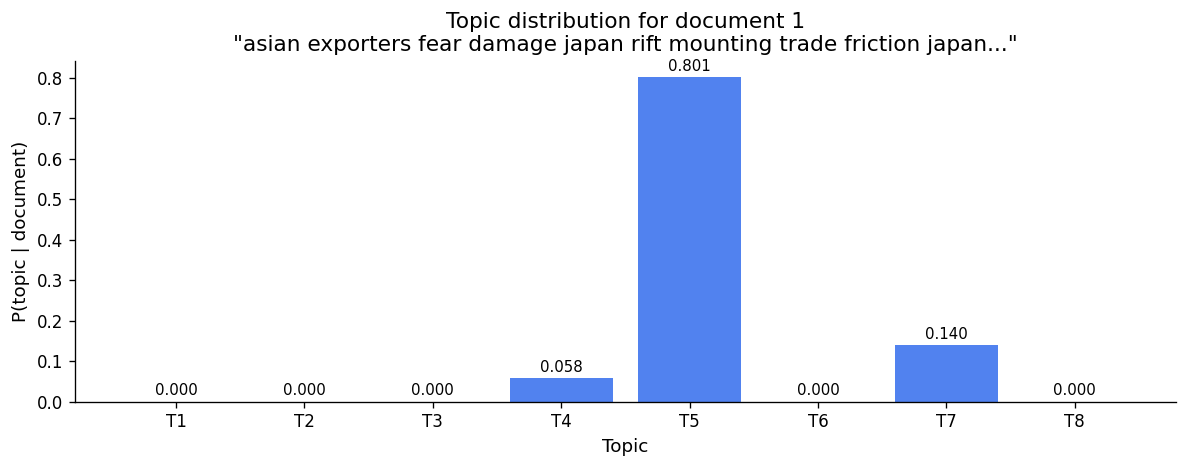

In [57]:
# 6.4 -- Topic Modeling with LDA
# LDA (Latent Dirichlet Allocation, Blei et al. 2003) models each document as a
# mixture of K latent topics, and each topic as a distribution over vocabulary.
#
# The generative story:
#   For each document d:
#     Draw topic mixture θ_d ~ Dir(α)
#     For each word position:
#       Draw topic z ~ Categorical(θ_d)
#       Draw word w ~ Categorical(β_z)
#
# Learning inverts this process via variational inference or Gibbs sampling.

from gensim import corpora, models
from nltk.corpus import reuters, stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import numpy as np

STOP = set(stopwords.words('english'))

# Prepare Reuters corpus
docs = []
for fid in reuters.fileids()[:500]:
    words = [w.lower() for w in reuters.words(fid)
             if w.isalpha() and w.lower() not in STOP and len(w) > 3]
    if len(words) > 10:
        docs.append(words)

dictionary = corpora.Dictionary(docs)
dictionary.filter_extremes(no_below=10, no_above=0.6, keep_n=5000)
corpus_bow  = [dictionary.doc2bow(d) for d in docs]

lda = models.LdaModel(corpus_bow, num_topics=8, id2word=dictionary,
                      passes=15, alpha='auto', eta='auto', random_state=42)

# Display topics
print('LDA Topics -- Reuters corpus (500 docs, 8 topics):')
print('─' * 60)
topic_labels = []
for i, topic in lda.print_topics(num_topics=8, num_words=8):
    words = [w.split('*')[1].strip().strip('"') for w in topic.split('+')]
    label = ' | '.join(words[:4])
    topic_labels.append(label)
    print(f'Topic {i+1:02d}: {"  ".join(words)}')

# Topic weight visualization for a sample document
sample_doc = corpus_bow[0]
topic_dist = lda.get_document_topics(sample_doc, minimum_probability=0)
weights = [w for _, w in sorted(topic_dist)]

plt.figure(figsize=(10, 4))
bars = plt.bar(range(1, 9), weights, color='#2563eb', alpha=0.8)
plt.bar_label(bars, fmt='%.3f', fontsize=9, padding=2)
plt.xticks(range(1, 9), [f'T{i}' for i in range(1, 9)])
plt.xlabel('Topic'); plt.ylabel('P(topic | document)')
plt.title(f'Topic distribution for document 1\n"{" ".join(docs[0][:10])}..."')
plt.tight_layout(); plt.show()

In [58]:
# 6.5 -- End-to-end NLP pipeline: from raw text to structured output
# This cell demonstrates a complete production-style pipeline.
# It chains: preprocess  embed  classify  extract entities  output JSON

import re, json
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk
from nltk.tree import Tree

STOP = set(stopwords.words('english'))
LEM  = WordNetLemmatizer()

def extract_entities(text):
    tokens = word_tokenize(text)
    tags   = pos_tag(tokens)
    tree   = ne_chunk(tags)
    entities = []
    for subtree in tree:
        if isinstance(subtree, Tree):
            entities.append({'text': ' '.join(w for w,_ in subtree.leaves()),
                             'type': subtree.label()})
    return entities

def extract_numbers(text):
    return re.findall(r'\$[\d,.]+(?:\s*(?:billion|million|thousand))?|\d+(?:\.\d+)?%', text)

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    return [LEM.lemmatize(t,'v') for t in tokens
            if t.isalpha() and t not in STOP and len(t) > 2]

# Simulated pipeline for a news article
article = """
Microsoft Corporation announced record quarterly earnings on Thursday, reporting
net income of $21.9 billion, a 20 percent increase year-over-year. CEO Satya Nadella
attributed the growth to strong demand for Azure cloud services and the company's
AI integration across its product lineup. Analysts at Goldman Sachs raised their
12-month price target to $450 per share.
""".strip()

result = {
    'sentences':   sent_tokenize(article),
    'tokens':      preprocess_text(article),
    'entities':    extract_entities(article),
    'numbers':     extract_numbers(article),
    'token_count': len(preprocess_text(article)),
}

# Feed to sentiment classifier from
try:
    result['sentiment'] = lr_pipe.predict([' '.join(result['tokens'])])[0]
    result['sentiment_confidence'] = float(lr_pipe.predict_proba([' '.join(result['tokens'])])[0].max())
except:
    result['sentiment'] = 'n/a (run  cells first)'

print('Pipeline output (structured JSON):')
print(json.dumps({k: v for k, v in result.items() if k != 'tokens'}, indent=2))
print(f'\nClean tokens: {result["tokens"][:12]}...')

Pipeline output (structured JSON):
{
  "sentences": [
    "Microsoft Corporation announced record quarterly earnings on Thursday, reporting\nnet income of $21.9 billion, a 20 percent increase year-over-year.",
    "CEO Satya Nadella\nattributed the growth to strong demand for Azure cloud services and the company's\nAI integration across its product lineup.",
    "Analysts at Goldman Sachs raised their\n12-month price target to $450 per share."
  ],
  "entities": [
    {
      "text": "Microsoft",
      "type": "PERSON"
    },
    {
      "text": "Corporation",
      "type": "ORGANIZATION"
    },
    {
      "text": "CEO Satya Nadella",
      "type": "ORGANIZATION"
    },
    {
      "text": "Azure",
      "type": "PERSON"
    },
    {
      "text": "Goldman Sachs",
      "type": "ORGANIZATION"
    }
  ],
  "numbers": [
    "$21.9 billion",
    "$450"
  ],
  "token_count": 36,
  "sentiment": "neg",
  "sentiment_confidence": 0.5562512844595209
}

Clean tokens: ['microsoft', 'corporation'

---